# Scalar finite-section error maps — Figure 4.1

## Imports and parameters

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import lambertw
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply

max_order = 100
x0_values = np.linspace(0.0, 1.0, 101)
time_points = 2001

## Model and Simulation Functions

For

$$
\dot{x}^{\pm}=\pm\frac{x^{\pm}}{1+(x^{\pm})^2},
$$

the time intervals used in Figure 4.1 are

$$
T_+^*(x_0)=
\max\left\{
\frac{e-1}{2e-1}\left(\ln |x_0|^{-1}-1\right),\,0.1
\right\},
\qquad
T_-^*=10.
$$

The maximum finite-section error is

$$
e^{\pm}(x_0,N)=
\sup_{0\leq t\leq T_{\pm}^*}
\left|y_{1,N}^{\pm}(t)-x^{\pm}(t)\right|,
$$

and the displayed logarithmic error is

$$
E^{\pm}(x_0,N)=
\log_{10}\!\left(
\min\left\{
\max\left\{e^{\pm}(x_0,N),10^{-15}\right\},10^5
\right\}
\right).
$$

In [3]:
def exact_solution(times, initial, sign):
    argument = initial**2 * np.exp(initial**2 + 2.0 * sign * times)
    return np.sqrt(lambertw(argument).real)


def positive_final_time(initial):
    if initial == 0.0:
        return 0.1

    return max(
        (np.e - 1.0) / (2.0 * np.e - 1.0)
        * (np.log(1.0 / initial) - 1.0),
        0.1,
    )


def carleman_matrix(order, sign):
    rows = []
    columns = []
    values = []

    for k in range(1, order + 1):
        for ell in range(k, order + 1, 2):
            rows.append(k - 1)
            columns.append(ell - 1)
            values.append(sign * k * (-1) ** ((ell - k) // 2))

    return csr_matrix(
        (values, (rows, columns)),
        shape=(order, order),
        dtype=float,
    )


def first_row_coefficients(matrix, times):
    basis = np.zeros(matrix.shape[0])
    basis[0] = 1.0

    return expm_multiply(
        matrix.T,
        basis,
        start=float(times[0]),
        stop=float(times[-1]),
        num=times.size,
        endpoint=True,
        traceA=float(matrix.diagonal().sum()),
    )


def error_map(sign):
    matrix = carleman_matrix(max_order, sign)
    degrees = np.arange(1, max_order + 1)
    powers = x0_values[None, :] ** degrees[:, None]

    if sign > 0:
        final_times = np.array([positive_final_time(value) for value in x0_values])
    else:
        final_times = np.full(x0_values.size, 10.0)

    times = np.linspace(0.0, final_times.max(), time_points)
    coefficients = first_row_coefficients(matrix, times)
    exact = exact_solution(times[:, None], x0_values[None, :], sign)
    valid_times = times[:, None] <= final_times[None, :]

    endpoint_basis = np.zeros(max_order)
    endpoint_basis[0] = 1.0
    endpoint_coefficients = np.empty((x0_values.size, max_order))

    for index, final_time in enumerate(final_times):
        endpoint_coefficients[index] = expm_multiply(
            matrix.T * final_time,
            endpoint_basis,
            traceA=float(matrix.diagonal().sum() * final_time),
        )

    endpoint_exact = exact_solution(final_times, x0_values, sign)
    sampled_approximation = np.zeros_like(exact)
    endpoint_approximation = np.zeros(x0_values.size)
    errors = np.empty((max_order, x0_values.size))

    for order_index in range(max_order):
        sampled_approximation += coefficients[:, order_index, None] * powers[order_index]
        endpoint_approximation += endpoint_coefficients[:, order_index] * powers[order_index]

        sampled_error = np.where(
            valid_times,
            np.abs(sampled_approximation - exact),
            -np.inf,
        ).max(axis=0)
        endpoint_error = np.abs(endpoint_approximation - endpoint_exact)
        errors[order_index] = np.maximum(sampled_error, endpoint_error)

    errors[:, 0] = 0.0
    display = np.log10(np.clip(errors, 1e-15, 1e5))
    
    return display, errors, matrix

## Simulation

In [4]:
positive_display, positive_errors, positive_matrix = error_map(1)
negative_display, negative_errors, negative_matrix = error_map(-1)

check_times = np.linspace(0.0, 0.4, 401)
check_initial = 0.2
check_order = 19
check_matrix = carleman_matrix(check_order, 1)
check_lifted = check_initial ** np.arange(1, check_order + 1)

direct = expm_multiply(
    check_matrix,
    check_lifted,
    start=0.0,
    stop=0.4,
    num=check_times.size,
    endpoint=True,
    traceA=float(check_matrix.diagonal().sum()),
)[:, 0]

nested = first_row_coefficients(positive_matrix, check_times)[:, :check_order] @ check_lifted
numerical = solve_ivp(
    lambda _, state: state / (1.0 + state**2),
    (0.0, 0.4),
    [check_initial],
    t_eval=check_times,
    rtol=1e-12,
    atol=1e-14,
).y[0]

nested_check = np.max(np.abs(direct - nested))
exact_check = np.max(
    np.abs(numerical - exact_solution(check_times, check_initial, 1))
)

## Results

Nested finite-section check: 3.053e-16
Exact solution check:       1.126e-13
All computed errors finite:  True


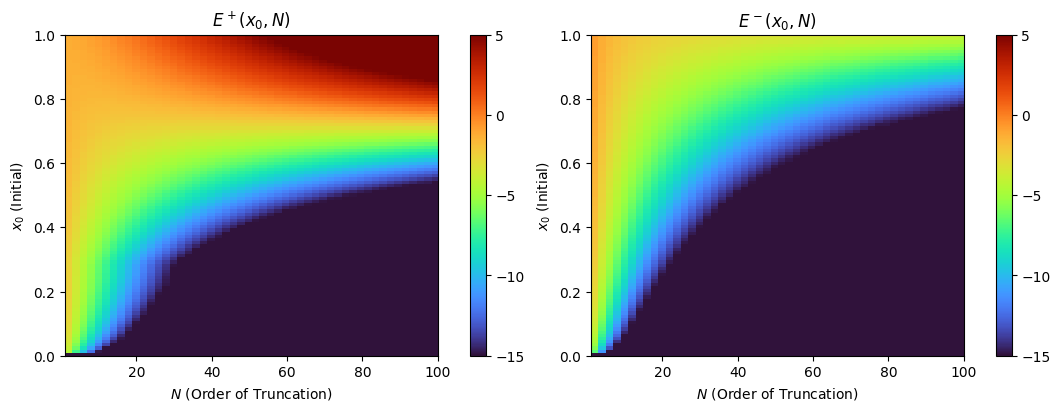

: 

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
extent = [1, max_order, 0.0, 1.0]

for axis, values, title in [
    (axes[0], positive_display, r"$E^+(x_0,N)$"),
    (axes[1], negative_display, r"$E^-(x_0,N)$"),
]:
    image = axis.imshow(
        values.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="turbo",
        vmin=-15,
        vmax=5,
    )
    axis.set_title(title)
    axis.set_xlabel(r"$N$ (Order of Truncation)")
    axis.set_ylabel(r"$x_0$ (Initial)")
    figure.colorbar(image, ax=axis, ticks=[-15, -10, -5, 0, 5])


print(f"Nested finite-section check: {nested_check:.3e}")
print(f"Exact solution check:       {exact_check:.3e}")
print(
    "All computed errors finite:  "
    f"{np.isfinite(positive_errors).all() and np.isfinite(negative_errors).all()}"
)